# Asistente Inteligente para Seguridad Urbana en Costa Rica
### Módulos del Asistente Inteligente — RNN Predicción de incidencias
### Módulo 2: Predicción temporal de zonas y horarios de riesgo
### Integrantes :
### Profesor:

## 1. Importación de librerías


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

#  2. Cargar datos


In [39]:
df = pd.read_csv("C:\SmartCityIA\data\Estadisticas OIJ.csv")

df.head()

,Delito,SubDelito,Fecha,Rango Horario,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton
0,ASALTO,ARMA BLANCA,01/02/2022,12:00:00 - 14:59:59,VEHICULO,MOTOCICLETA/REPARTIDOR [VEHICULO],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,ASERRI
1,ASALTO,ARMA BLANCA,03/02/2022,18:00:00 - 20:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,ALAJUELA,ALAJUELA
2,ASALTO,ARMA BLANCA,04/02/2022,09:00:00 - 11:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE
3,ASALTO,ARMA BLANCA,06/02/2022,03:00:00 - 05:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE
4,ASALTO,ARMA BLANCA,08/02/2022,00:00:00 - 02:59:59,PERSONA,TURISTA/EXTRANJERO [PERSONA],Mayor de edad,HOMBRE,RUSIA,PUNTARENAS,GARABITO


# 3. Conversion de fecha

In [40]:
df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True)

df = df.sort_values('Fecha')

# Serie Temporal

In [41]:
serie = df.groupby("Fecha").size()

serie = serie.to_frame(name="Delitos")

serie.head()

serie.head()

,Delitos
Fecha,
2022-02-01,95
2022-02-02,110
2022-02-03,112
2022-02-04,143
2022-02-05,145


# Vizualizacion de la serie tempral

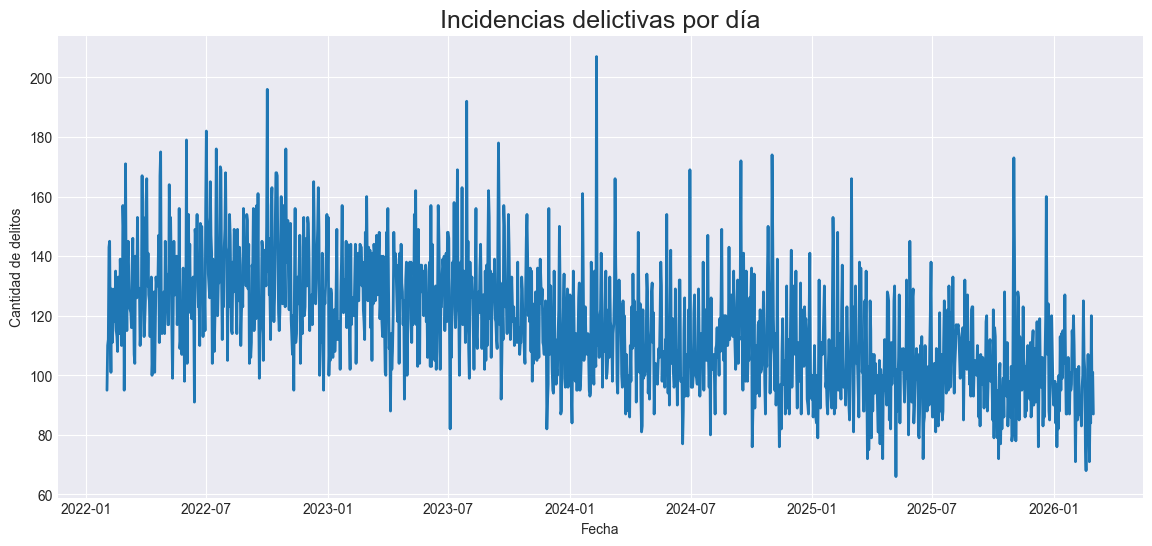

In [42]:
plt.figure(figsize=(14,6))

plt.plot(serie.index, serie["Delitos"], linewidth=2)

plt.title("Incidencias delictivas por día", fontsize=18)
plt.xlabel("Fecha")
plt.ylabel("Cantidad de delitos")

plt.grid(True)

plt.show()

# Normalizacion

In [43]:
scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(serie)

# Secuencias RNN

In [45]:
window = 30

X = []
y = []

for i in range(window, len(data_scaled)):

    X.append(data_scaled[i-window:i])
    y.append(data_scaled[i])

X = np.array(X)
y = np.array(y)

print(X.shape)

(1460, 30, 1)


# Train / Test

In [46]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Modelo LSTM

In [47]:
model = Sequential()

model.add(LSTM(100, return_sequences=True, input_shape=(X_train.shape[1],1)))

model.add(LSTM(50))

model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 30, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

# Entranamiento de Modelo

In [96]:
history = model.fit(

    X_train,
    y_train,

    epochs=20,
    batch_size=32,

    validation_data=(X_test,y_test)
)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0116 - val_loss: 0.0128
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0116 - val_loss: 0.0115
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0119 - val_loss: 0.0119
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0117 - val_loss: 0.0092
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0116 - val_loss: 0.0129
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0117 - val_loss: 0.0100
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0119 - val_loss: 0.0126
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0116 - val_loss: 0.0095
Epoch 9/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0118 - val_loss: 0.0098
Epoch 10/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0119 - val_loss: 0.0099
Epoch 11/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0118 - val_loss: 0.0102
Epoch 12/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0

# Prediccion

In [97]:
pred = model.predict(X_test)

pred = scaler.inverse_transform(pred)
y_real = scaler.inverse_transform(y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


# Grafico de Perdida

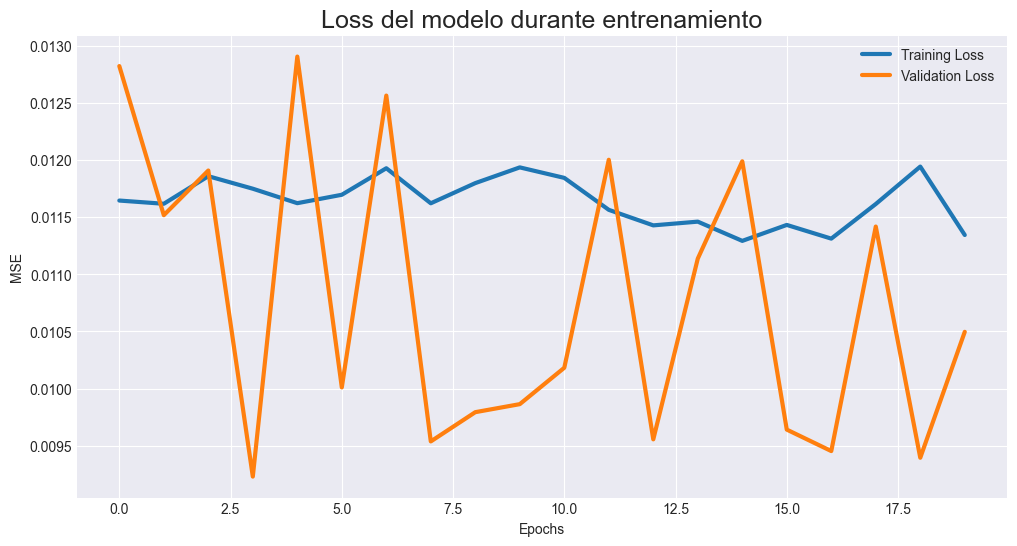

In [98]:
plt.figure(figsize=(12,6))

plt.plot(history.history["loss"], linewidth=3)
plt.plot(history.history["val_loss"], linewidth=3)

plt.title("Loss del modelo durante entrenamiento", fontsize=18)

plt.xlabel("Epochs")
plt.ylabel("MSE")

plt.legend(["Training Loss","Validation Loss"])

plt.grid(True)

plt.show()

# Comparacion

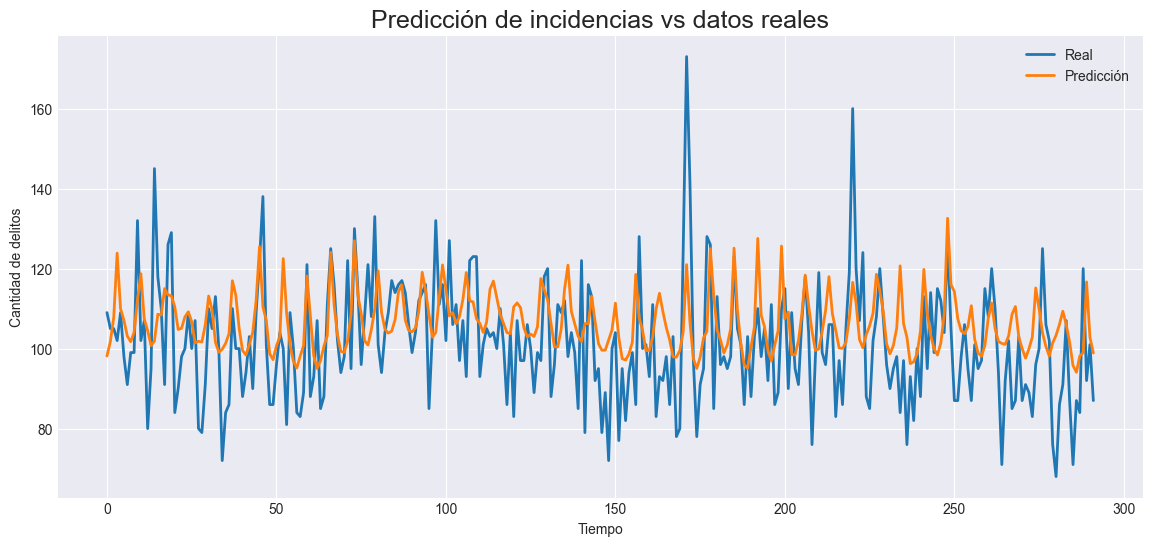

In [99]:
plt.figure(figsize=(14,6))

plt.plot(y_real, linewidth=2)
plt.plot(pred, linewidth=2)

plt.title("Predicción de incidencias vs datos reales", fontsize=18)

plt.xlabel("Tiempo")
plt.ylabel("Cantidad de delitos")

plt.legend(["Real","Predicción"])

plt.grid(True)

plt.show()

# Metricas

In [100]:
mae = mean_absolute_error(y_real, pred)

rmse = np.sqrt(mean_squared_error(y_real, pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 11.260695836315417
RMSE: 14.445805798981093


# Prediccion futura

In [101]:
last_window = data_scaled[-30:]

future_predictions = []

current_window = last_window.copy()

for i in range(4):

    pred = model.predict(current_window.reshape(1,30,1))

    future_predictions.append(pred[0,0])

    current_window = np.append(current_window[1:], pred)

future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1,1))

print("Predicción futura:", future_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Predicción futura: [[ 95.845985]
 [ 97.27137 ]
 [100.07108 ]
 [102.263115]]
